In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()
LAB_PATH = os.getenv('LAB_PATH')

In [ ]:
# --- Configuration ---
# Group all folder paths into a dictionary for better organization.
# The keys are descriptive names for your datasets.
DATASETS = {
    "Arctique Semantic (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/arctique/blood_cells_0_00/semantic/dropout/pu/",
    "Arctique Semantic (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/arctique/blood_cells_0_75/semantic/dropout/pu/",
    "Arctique Instance (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/arctique/nuclei_intensity_0_00/instance/dropout/pu/",
    "Arctique Instance (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/arctique/nuclei_intensity_0_50/instance/dropout/pu/",
    
    "LIDC Malignancy (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lidc/malignancy_0_00/fgbg/dropout/pu/",
    "LIDC Malignancy (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lidc/malignancy_1_00/fgbg/dropout/pu/",
    "LIDC Texture (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lidc/texture_0_00/fgbg/dropout/pu/",
    "LIDC Texture (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lidc/texture_1_00/fgbg/dropout/pu/",

    "Worm Nematodes (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/wormbodies/nematodes_0_00/fgbg/dropout/pu/",
    "Worm Nematodes (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/wormbodies/nematodes_1_00/fgbg/dropout/pu/",
    "Worm Protists (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/wormbodies/protists_0_00/fgbg/dropout/pu/",
    "Worm Protists (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/wormbodies/protists_1_00/fgbg/dropout/pu/",

    "GTA Cityscapes (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/gta/cityscapes_0_00/semantic/dropout/pu/",
    "GTA Cityscapes (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/gta/cityscapes_1_00/semantic/dropout/pu/",

    "Weeds Maize (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/weedsgalore/maize_0_00/crops_vs_weed/dropout/pu/",
    "Weeds Maize (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/weedsgalore/maize_1_00/crops_vs_weed/dropout/pu/",
    
    "Lizard GLAS Semantic (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lizard/glas_set_0_00/semantic/dropout/pu/",
    "Lizard GLAS Semantic (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lizard/glas_set_1_00/semantic/dropout/pu/",
    "Lizard GLAS Instance (ID)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lizard/glas_set_0_00/instance/dropout/pu/",
    "Lizard GLAS Instance (OOD)": LAB_PATH + "data/AggroUQ_eval_samples_vis/lizard/glas_set_1_00/instance/dropout/pu/",
}

# --- Helper Function ---
def count_files_in_directory(path: str) -> int:
    """
    Counts the number of files in a given directory path.
    Returns 0 if the directory does not exist or is empty.
    """
    if not os.path.isdir(path):
        print(f"Warning: Directory not found at {path}")
        return 0
    
    # This is your original logic for counting files
    return len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])

# --- Main Execution ---
print("="*50)
print("       AggroUQ Evaluation Sample Counts")
print("="*50)

# Iterate through the dictionary and print formatted results
for name, path in DATASETS.items():
    file_count = count_files_in_directory(path)
    # Print the name left-aligned in 30 characters and the count
    print(f"{name:<35}: {file_count} samples")

print("="*50)

       AggroUQ Evaluation Sample Counts
Arctique Semantic (ID)             : 25 samples
Arctique Semantic (OOD)            : 50 samples
Arctique Instance (ID)             : 25 samples
Arctique Instance (OOD)            : 50 samples
LIDC Malignancy (ID)               : 53 samples
LIDC Malignancy (OOD)              : 93 samples
LIDC Texture (ID)                  : 84 samples
LIDC Texture (OOD)                 : 20 samples
Worm Nematodes (ID)                : 25 samples
Worm Nematodes (OOD)               : 47 samples
Worm Protists (ID)                 : 25 samples
Worm Protists (OOD)                : 82 samples
GTA Cityscapes (ID)                : 300 samples
GTA Cityscapes (OOD)               : 300 samples
Weeds Maize (ID)                   : 26 samples
Weeds Maize (OOD)                  : 159 samples
Lizard GLAS Semantic (ID)          : 193 samples
Lizard GLAS Semantic (OOD)         : 356 samples
Lizard GLAS Instance (ID)          : 193 samples
Lizard GLAS Instance (OOD)         : 356 s


      Visualizing First Sample from Each Dataset


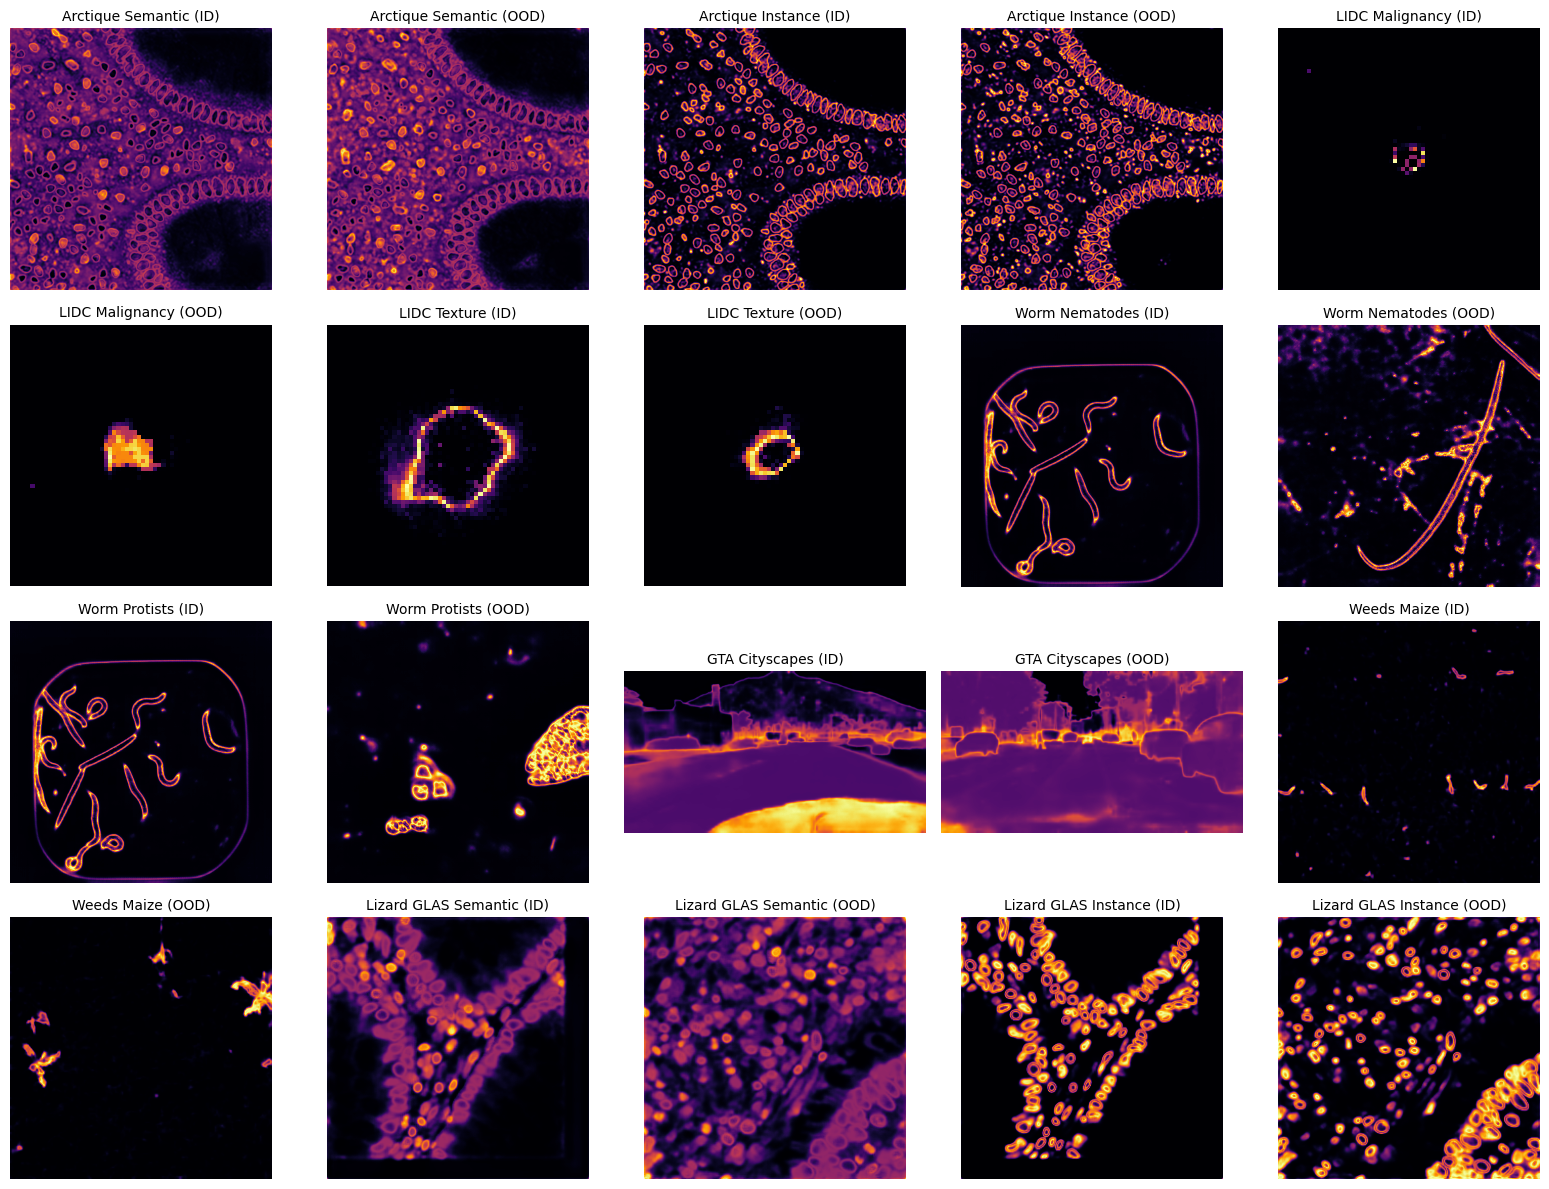

<Figure size 640x480 with 0 Axes>

In [8]:
# --- Helper Function for Visualization ---
def visualize_first_samples(datasets: dict):
    """
    Creates a 4x5 subplot grid displaying the first sample from each dataset folder.
    """
    print("\n" + "="*50)
    print("      Visualizing First Sample from Each Dataset")
    print("="*50)
    
    # Create a 4x5 grid of subplots. figsize is adjusted for readability.
    fig, axes = plt.subplots(4, 5, figsize=(16, 12))
    
    # Flatten the 2D array of axes into a 1D array for easy iteration
    axes = axes.flatten()

    # Iterate through the datasets and their corresponding subplots
    for i, (name, path) in enumerate(datasets.items()):
        ax = axes[i]
        
        # Default title in case the folder is empty or doesn't exist
        ax.set_title(name, fontsize=10)
        ax.axis('off') # Turn off the axis ticks and labels

        if not os.path.isdir(path):
            ax.text(0.5, 0.5, 'Not Found', ha='center', va='center')
            continue

        # Find all files in the directory
        files = sorted([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        
        if files:
            try:
                # Construct the full path to the first file and load it
                first_file_path = os.path.join(path, files[0])
                data = np.load(first_file_path)
                
                # Display the data using the 'viridis' colormap
                ax.imshow(data, cmap='inferno')
            except Exception as e:
                # If loading fails, display an error on the subplot
                ax.text(0.5, 0.5, 'Load Error', ha='center', va='center')
                print(f"Could not load file from {name}: {e}")
        else:
            # If no files are found, display a message on the subplot
            ax.text(0.5, 0.5, 'Empty Folder', ha='center', va='center')

    # Use tight_layout to prevent titles from overlapping
    plt.tight_layout()
    plt.show()
    plt.tight_layout()
    
    output_filename="overview_eval_uq_maps.png"
    save_path = os.path.join(os.getcwd(), output_filename)
    fig.savefig(save_path, bbox_inches='tight', dpi=150)

visualize_first_samples(DATASETS)